In [ ]:
#combined metric for presentation

In [ ]:
import pandas as pd

# Load the three tabs from the Excel
restaurants = pd.read_excel("foodie_metrics.xlsx", sheet_name="Restaurant Density")
diversity = pd.read_excel("foodie_metrics.xlsx", sheet_name="Diversity")
fresh = pd.read_excel("foodie_metrics.xlsx", sheet_name="Fresh Food Access")

# Standardize column names: keep neighborhood + score from each tab
rest = restaurants[["Neighborhood", "Score"]].rename(columns={"Score": "rest_score"})
div = diversity[["Neighborhood", "Diversity Score"]].rename(columns={"Diversity Score": "div_score"})
frsh = fresh[["Neighborhood", "Score"]].rename(columns={"Score": "fresh_score"})

# Merge all three on neighborhood 
df = rest.merge(div, on="Neighborhood", how="outer").merge(frsh, on="Neighborhood", how="outer")

# Rank each metric (higher score = better rank)
df["rest_rank"] = df["rest_score"].rank(ascending=False, method="min")
df["div_rank"] = df["div_score"].rank(ascending=False, method="min")
df["fresh_rank"] = df["fresh_score"].rank(ascending=False, method="min")

# Neighborhoods missing from diversity get a tied last-place rank
df["div_rank"] = df["div_rank"].fillna(df["div_rank"].max() + 1)

# Weighted average rank: restaurants 40%, diversity 40%, fresh food 20%
df["avg_rank"] = (0.4 * df["rest_rank"]) + (0.4 * df["div_rank"]) + (0.2 * df["fresh_rank"])

# Final ranking
df["final_rank"] = df["avg_rank"].rank(method="min").astype(int)
df = df.sort_values("avg_rank")

df[["Neighborhood", "rest_rank", "div_rank", "fresh_rank", "avg_rank", "final_rank"]].head(20)

,Neighborhood,rest_rank,div_rank,fresh_rank,avg_rank,final_rank
8,Bloomfield,9.0,1.0,13.0,6.6,1
3,Strip District,4.0,3.0,20.0,6.8,2
9,Bluff,10.0,2.0,22.0,9.2,3
14,East Liberty,15.0,8.0,3.0,9.8,4
4,South Side Flats,5.0,9.0,21.0,9.8,5
12,Crawford-Roberts,13.0,4.0,23.0,11.4,6
0,Central Business District,1.0,14.0,30.0,12.0,7
11,Central Northside,12.0,10.0,17.0,12.2,8
2,Central Oakland,3.0,13.0,40.0,14.4,9
1,North Shore,2.0,15.0,40.0,14.8,10


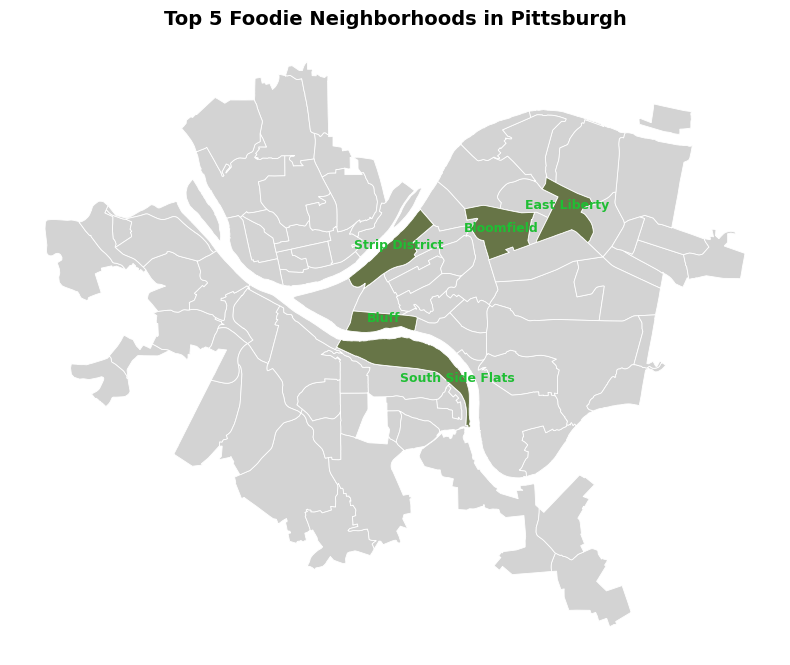

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load neighborhoods
hoods = gpd.read_file("neighborhoods.geojson").to_crs("EPSG:2272")

# Get top 5 neighborhood names from final ranking
top5_names = df.head(5)["Neighborhood"].tolist()

# Flag each neighborhood() top 5 or not
hoods["is_top5"] = hoods["hood"].isin(top5_names)

# GeoPlot
fig, ax = plt.subplots(figsize=(8, 10))
hoods.plot(color="lightgrey", edgecolor="white", linewidth=0.6, ax=ax)
hoods[hoods["is_top5"]].plot(color="#677547", edgecolor="white", linewidth=0.6, ax=ax)

# Label the top 5 
for _, row in hoods[hoods["is_top5"]].iterrows():
    pt = row.geometry.representative_point()
    ax.annotate(row["hood"], xy=(pt.x, pt.y), ha="center", fontsize=9,
                fontweight="bold", color="#1FBE34")

ax.set_title("Top 5 Foodie Neighborhoods in Pittsburgh", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()